# Analiza kompromisu
Zbadamy wpływ zamrażania wybranych warstw (dalej **frozen**) oraz doboru learning rate (dalej **lr**, jak bardzo możemy modyfikować wagi - im większy tym bardziej możemy modyfikować) na jakość i czas trening. Następnie dokonamy analizy kompromisu między dokładnością a zużyciem zasobów obliczeniowych.


## Plan działania

Kroki *za kulisami*:

1.   Wytrenowanie 9 modeli BERT dla różnych wartości parametrów **lr** $\in \{1 \cdot 10^{-5}, 2 \cdot 10^{-5}, 5 \cdot 10^{-5}\}$ oraz **frozen** $\in \{0, 3, 5\}$ na zbiorze `enronSpamSubset`.
2.   Wybór najlepszego checkpointu dla każdego stworzonego w ten sposób modelu - powstaje super model.
3.   Przetestowanie każdego super modelu na 4 zbiorach danych:

      *   `lingspam`,
      *   `enronSpamSubset`,
      *   `spam`,
      *   `email_text`.
  
Pozostałe kroki:

4.   Rysujemy wykresy przetestowanych super modeli na różnych zbiorach danych i analizujemy zależność **accuracy** i **f1** od **lr** i **frozen**.
5.   Rysujemy wykresy dla zasobów zużytych podczas **treningu modeli!** i analizujemy w zależności od **lr** i **frozen**.
6.   Rysujemy wykres rozrzutu, który pozwala odpowiedzieć na pytanie odnośnie kompromisu - obliczamy średnią z wyników f1 wszystkich testów dla danego modelu na obcych zbiorach i porównujemy z czasem treningu i zużyciem zasobów.


Na początku warto zaznaczyć, że już sam wybór odpowiednich checkpointów dla każdego modelu opierał się na kompromisie między dopasowaniem modelu a liczbą kroków, w których się on uczył. Niejednokrotnie trafił się przypadek, że miary `eval_accuracy`, `eval_f1` oraz `eval_loss` przemawiały za wyborem modelu np. do kroku 1500, ale my wybraliśmy model do kroku 950, ponieważ różnice w wartościach tych miar były niewielkie, a w liczbie kroków treningu znaczące.

Ponadto checkpointy zostały wybrane tak, aby wszystkie super modele miały jak najbardziej zbliżoną liczbę wytrenowanych kroków. Pozwala to na zmniejszenie ryzyka, że któryś z modeli uległ przeuczeniu, bo miał dużo więcej czasu na naukę niż pozostałe.


## Ładowanie potrzebnych zasobów


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df_wyniki = pd.read_csv("/content/drive/MyDrive/Projekt_Transformer_Grupa_2/programy/druga_czesc/wyniki9.csv", encoding="utf-8")
df_zuzyciezasobow = pd.read_csv("/content/drive/MyDrive/Projekt_Transformer_Grupa_2/programy/druga_czesc/zuzyciezasobow9.csv", encoding="utf-8")

Mounted at /content/drive


Podłączenie R

In [ ]:
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
%%R -i df_wyniki -i df_zuzyciezasobow
# wczytujemy tabelki z Pythona do R i ładujemy biblioteki
library(ggplot2)
library(dplyr)
library(tidyr)

##### Podgląd tabelek z danymi

In [ ]:
%%R

df_wyniki$frozen <- as.factor(df_wyniki$frozen)
df_wyniki$lr <- as.factor(df_wyniki$lr)

print("WYNIKI")
print(head(df_wyniki))

[1] "WYNIKI"
        model         dataset frozen    lr accuracy precision  recall      f1
0 1e-05_0_950        lingSpam      0 1e-05  0.81166   0.46319 0.96690 0.62634
1 1e-05_0_950 enronSpamSubset      0 1e-05  0.99711   0.99539 0.99874 0.99706
2 1e-05_0_950            spam      0 1e-05  0.43863   0.17800 0.97192 0.30089
3 1e-05_0_950      email_text      0 1e-05  0.65771   0.62020 0.99606 0.76443
4 1e-05_3_850        lingSpam      3 1e-05  0.75222   0.39481 0.97163 0.56148
5 1e-05_3_850 enronSpamSubset      3 1e-05  0.99535   0.99475 0.99580 0.99528


In [ ]:
%%R

df_zuzyciezasobow$how_many_frozen <- as.factor(df_zuzyciezasobow$how_many_frozen)
df_zuzyciezasobow$learning_rate <- as.factor(df_zuzyciezasobow$learning_rate)

print("ZUŻYCIE ZASOBÓW")
print(head(df_zuzyciezasobow))

[1] "ZUŻYCIE ZASOBÓW"
             data how_many_frozen learning_rate   time_s   ram_mb  cpu_avg
0 enronSpamSubset               0         1e-05 2657.188 3844.570 45.07106
1 enronSpamSubset               0         2e-05 2454.544 3300.461 47.20158
2 enronSpamSubset               3         2e-05 2384.502 3298.828 43.49930
3 enronSpamSubset               3         1e-05 1902.190 3300.367 50.09046
4 enronSpamSubset               5         2e-05 2124.661 3302.504 46.45192
5 enronSpamSubset               5         1e-05 1988.481 3296.613 43.17556
  gpu_max_mb
0       3797
1       2637
2       2157
3       2157
4       1845
5       1845


#### Funkcje pomocnicze

In [ ]:
%%R
rysuj.porownanie <- function(df,
                             miara) {

  # Przygotowanie danych
  df$frozen <- as.factor(df$frozen)

  # Tworzymy ładne etykiety dla paneli LR
  df$lr.label <- paste("LR:", df$lr)

  # Wykres
  ggplot(df, aes(x = frozen, y = !!sym(miara), fill = dataset)) +
    geom_bar(stat = "identity", position = position_dodge(width = 0.9), color = "black", width = 0.8) +

    facet_grid(lr.label ~ .) +

    # Kolory
    scale_fill_manual(values = c("#98fb98", "#fa8072", "#ffd700", "#40e0d0")) +

    # W geom_text:
    geom_text(aes(label = round(!!sym(miara), 5)),
              position = position_dodge(width = 0.9), # MUSI być takie samo jak w geom_bar
              vjust = -0.5,
              size = 3,
              fontface = "bold") +

    # Estetyka
    theme_bw() +
    labs(title = paste("Porównanie modeli: ", miara),
         x = "Liczba zamrożonych warstw (Frozen)",
         y = miara,
         fill = "Zbiór danych") +

    # Skala Y z zapasem na etykiety
    scale_y_continuous(limits = c(0, 1.15), breaks = seq(0, 1, 0.2)) +

    theme(
      plot.title = element_text(face = "bold", size = 20, hjust = 0.5),
      strip.background = element_rect(fill = "gray90"),
      strip.text = element_text(face = "bold", size = 11),
      legend.position = "bottom", # Legenda na dole, żeby wykres był szerszy
      panel.grid.minor = element_blank()
    )
}

---

## 4. Wykresy przetestowanych super modeli na różnych zbiorach danych

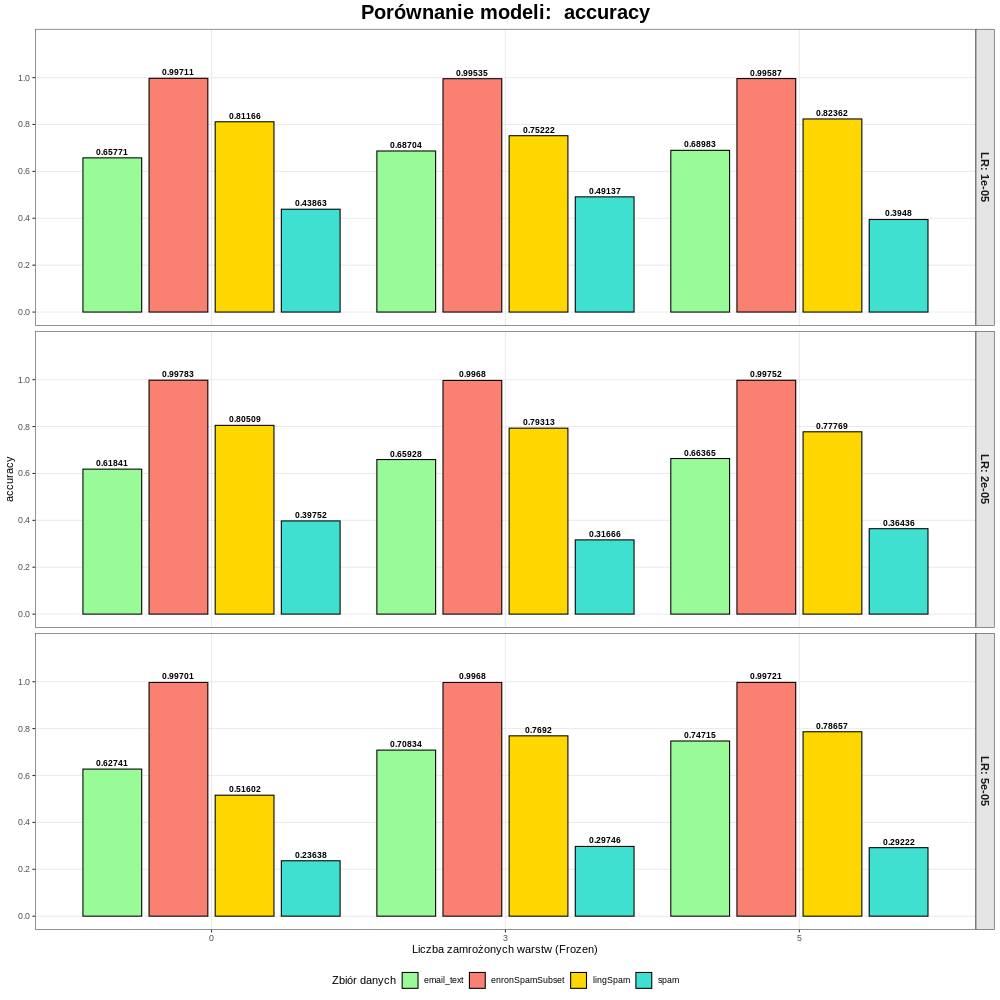

In [ ]:
%%R -w 1000 -h 1000 -u px

rysuj.porownanie(df_wyniki, "accuracy")

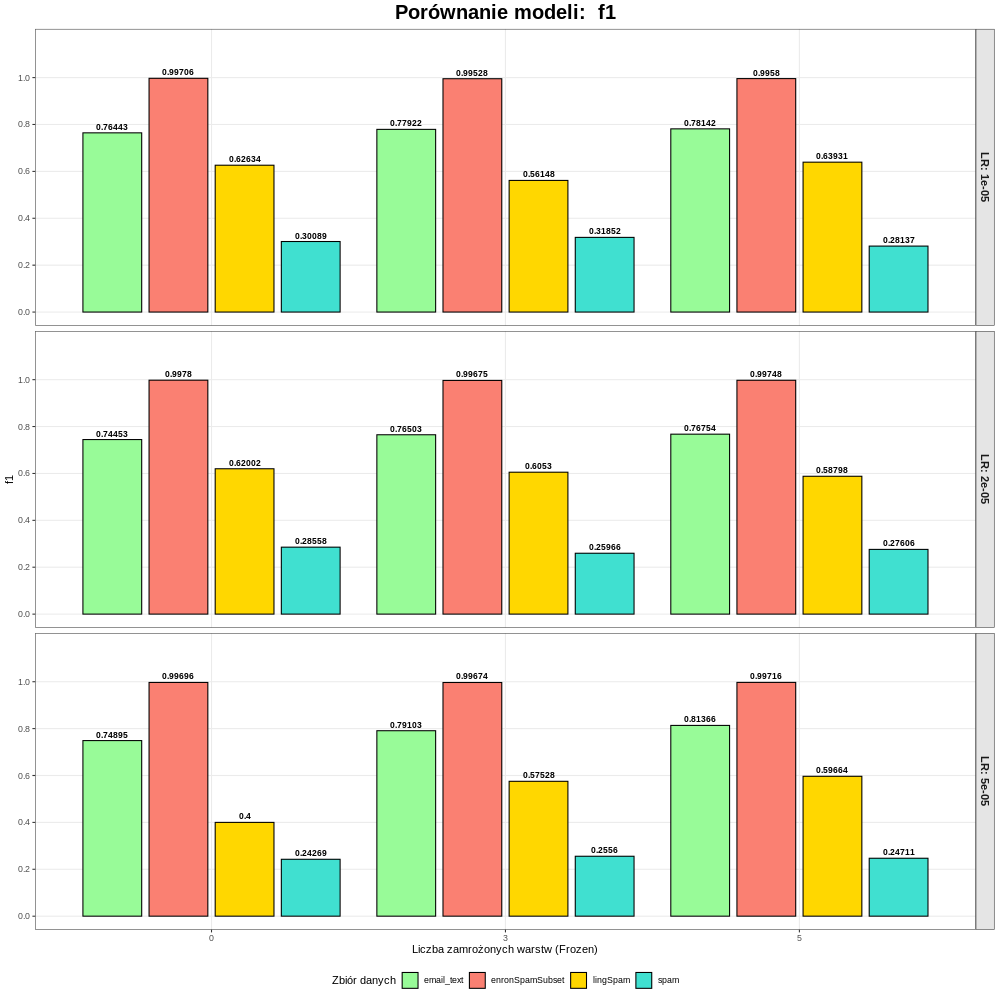

In [ ]:
%%R -w 1000 -h 1000 -u px

rysuj.porownanie(df_wyniki, "f1")

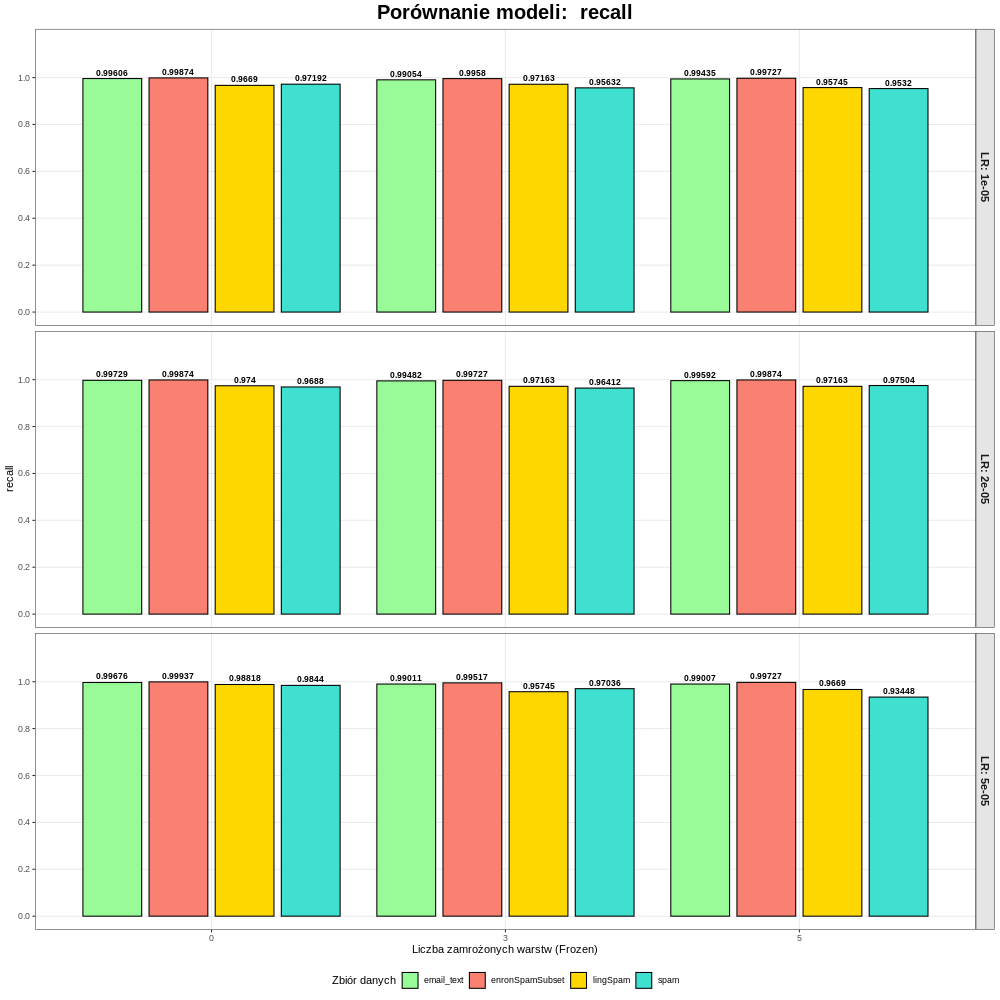

In [ ]:
%%R -w 1000 -h 1000 -u px

rysuj.porownanie(df_wyniki, "recall")

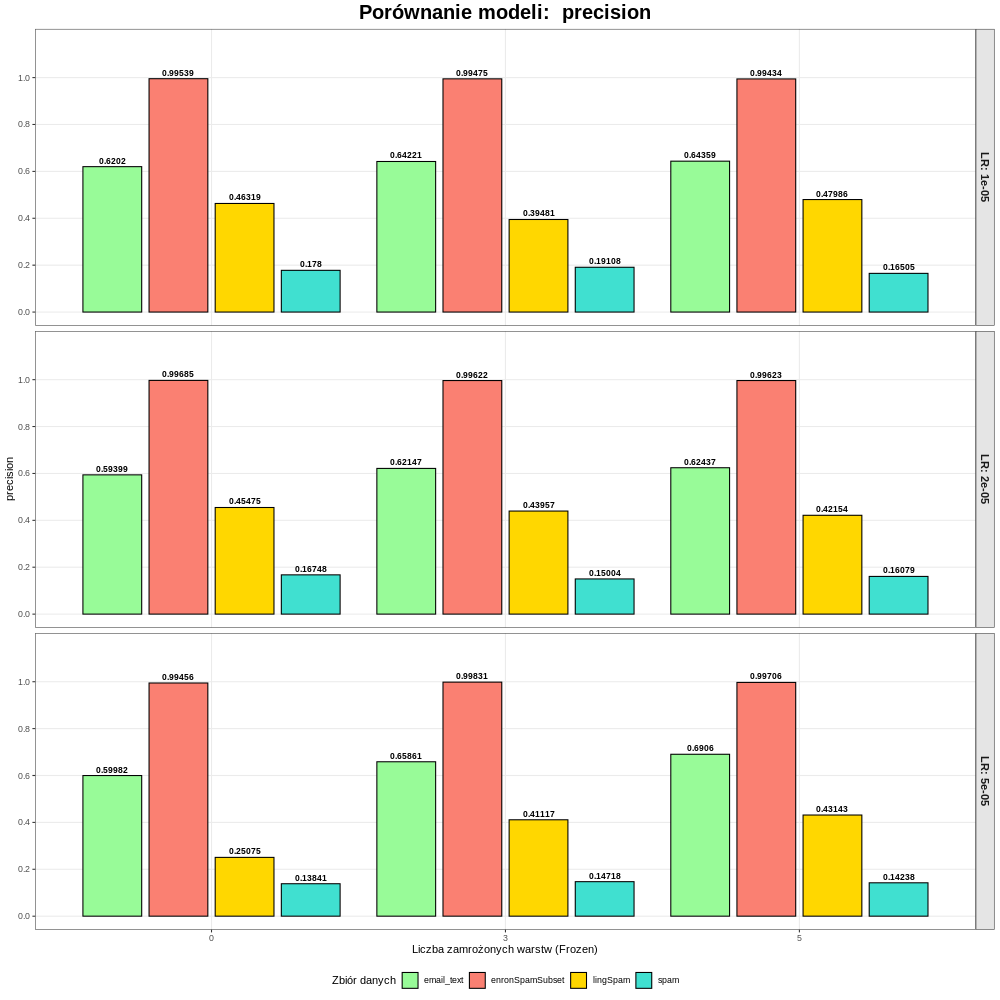

In [ ]:
%%R -w 1000 -h 1000 -u px

rysuj.porownanie(df_wyniki, "precision")

### Wnioski

#### Accuracy

Model najlepszej dopasowuje się do zbioru, na którym został wytrenowany (we wszystkich przypadkach dostajemy wyniki powyżej 99%). Dopasowanie na pozostałych zbiorach zależy od wybranego **frozen** oraz **lr**.

Dla dużego parametru uczenia (**lr** $= 5 \cdot 10^{-5}$) i braku zamrożonych
warstw (**frozen** = 0) wyniki dla wszystkich nowych zbiorów są tragiczne. Wynika to z faktu, że model dzięki dużej możliwości ingerowania w wagi bardzo dopasowuje się do zbioru, na którym był uczony, więc gdy ma dostęp do wszystkich tak zmodyfikowanych wag nie jest w stanie dobrze dopasowywać nowych zbiorów - traci elastyczność klasyfikacji. Średnio najoptymalniejszym wyborem dla **lr** $= 1 \cdot 10^{-5}$ jest minimalna możliwość ingerowania w wagi. Pozwala to modelowi na bezpieczne dostrojenie się do zadania, chroniąc jednocześnie pretrenowaną wiedzę.

Wartość tego parametru **lr** $= 1 \cdot 10^{-5}$ niezależnie od **frozen** bardzo podpasowała zbiorowi `lingspam`. Wypadał on najlepiej w kwestii dopasowania w każdym możliwym przypadku (należy mieć jednak na uwadze, że jest to stosunkowo mały zbiór). Po odpowiednim dobraniu parametrów `email_text` (zbiór o bardzo dużej liczbie przypadków) jest w stanie dorównać wynikom poprzednika (**lr** $= 5 \cdot 10^{-5}$ i **frozen** $= 5$). Duża liczba danych w tym zbiorze pozwala na bezpieczne zrównoważnie wpływu wyższego współczynnika uczenia, a mrożenie warstw na zachowanie ogólnych wzorców modelu.

#### F1

Pomimo faktu, że `lingspam` wygrywa ze wszystkimi obcymi zbiorami w kwestii dopasowania, to `email_text` okazał się najdokładniejszy w swoich działaniach niezależnie od wartości parametrów. Najlepsze wyniki osiąga dla **frozen** $= 5$, co potwierdza poprzednie wnioski. Podobnie jest z najgorszym przypadkiem dla wszystkich modeli **lr** $= 1 \cdot 10^{-5}$ i **frozen** = 0.

#### Recall i precision (precyzja)

Porównanie tych dwóch miar pozwala nam wywnioskować, którą grupę (spam czy niespam) modele klasyfikowały lepiej. Jak widać, w każdym przypadku, niezależnie od zbioru danych i wartości parametrów, otrzymujemy fantastyczne wyniki recall przy fatalnej precyzji (wyjątek `email_text` - wyniki są umiarkowane). Możemy zatem podejrzewać, że modele wręcz wybitnie radzą sobie z klasyfikacją spamu, ale źle z normalnymi mailami - wrzucają zdecydowaną większość maili do spamu, zatem spam wyłapują idealnie, a niespam słabo.


Podsumowując, wpływ paramtru uczenia oraz liczby zamrożonych warstw ma znaczny wpływ na jakość klasyfikacji na obcych zbiorach danych. Duże znaczenie ma również podobieństwo proporcji danych w zbiorze testowym do zbioru treningowego - jedyny obcy z zbiór, z którym nasz wytrenowany na `enronSpamSubset` BERT radzi sobie prawdziwie dobrze jest `email_text` (bardzo podobne proporcje spamu do niespamu).


---

## 5. Wykresy przedstawiające zużycia zasobów podczas treningu modelu

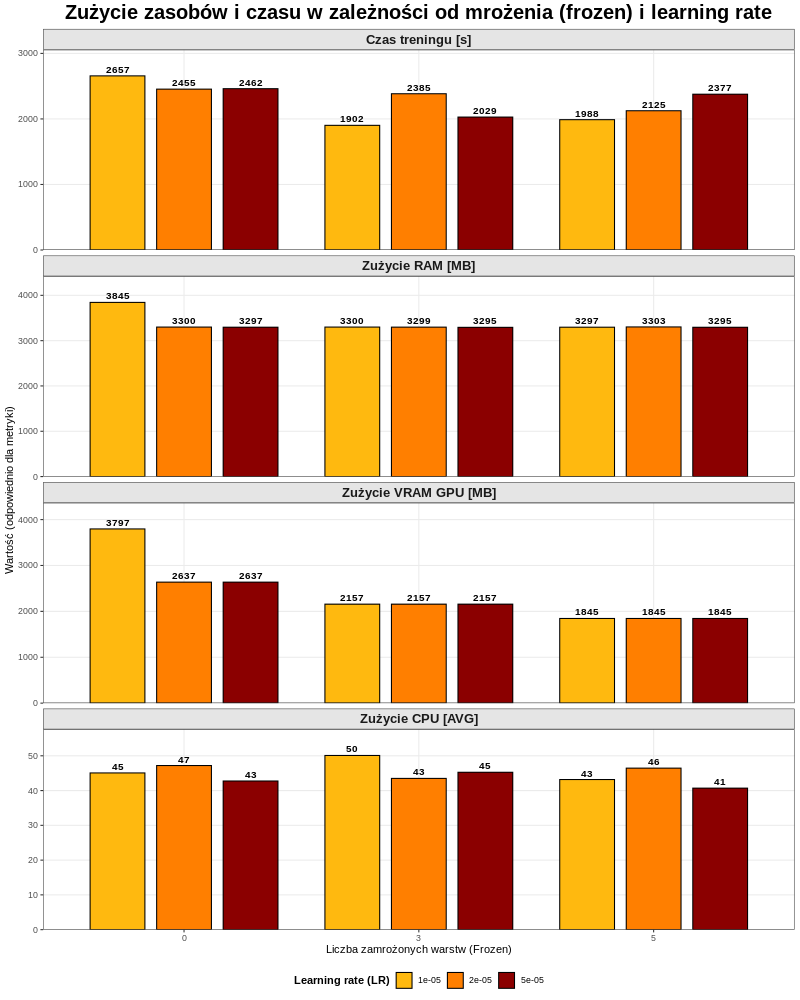

In [ ]:
%%R -w 800 -h 1000 -u px

df_zasoby <- df_zuzyciezasobow %>%
  select(how_many_frozen, learning_rate, time_s, ram_mb, gpu_max_mb, cpu_avg) %>%
  pivot_longer(cols = c(time_s, ram_mb, gpu_max_mb, cpu_avg),
               names_to = "Metryka",
               values_to = "Wartość")

df_zasoby$Metryka <- factor(df_zasoby$Metryka,
                            levels = c("time_s", "ram_mb", "gpu_max_mb", "cpu_avg"),
                            labels = c("Czas treningu [s]", "Zużycie RAM [MB]", "Zużycie VRAM GPU [MB]", "Zużycie CPU [AVG]"))

# Tworzymy ostateczny wykres
ggplot(df_zasoby, aes(x = factor(how_many_frozen), y = Wartość, fill = factor(learning_rate))) +

  # Słupki obok siebie dla różnych lr
  geom_bar(stat = "identity", position = position_dodge(width = 0.85), color = "black", width = 0.7) +

  # Trzy osobne panele dla każdej z metryk (z uwolnioną osią Y!)
  facet_wrap(~ Metryka, scales = "free_y", ncol = 1) +

  # Dodanie dokładnych wartości nad słupkami
  geom_text(aes(label = round(Wartość, 0)),
            position = position_dodge(width = 0.85),
            vjust = -0.5, size = 3.5, fontface = "bold") +

  # Kolorystyka dla lr
  scale_fill_manual(values = c("1e-05" = "darkgoldenrod1",
                               "2e-05" = "darkorange1",
                               "5e-05" = "darkred")) +

  theme_bw() +
  labs(title = "Zużycie zasobów i czasu w zależności od mrożenia (frozen) i learning rate",
       x = "Liczba zamrożonych warstw (Frozen)",
       y = "Wartość (odpowiednio dla metryki)",
       fill = "Learning rate (LR)") +

  # Margines nad słupkami, żeby tekst nie uciekł za ramkę
  scale_y_continuous(expand = expansion(mult = c(0, 0.15))) +

  theme(
    plot.title = element_text(face = "bold", size = 20, hjust = 0.5),
    strip.background = element_rect(fill = "gray90"),
    strip.text = element_text(face = "bold", size = 13),
    legend.position = "bottom",
    legend.title = element_text(face = "bold"),
    panel.grid.minor = element_blank()
  )

### Wnioski

Modele bez mrożenia, niezależnie od parametru **lr**, wykorzystują najwięcej zasobów. Im więcej warstw jest zamrożonych, tym mniejsze zużycie karty graficznej (VRAM). Wynika to z tego, że model nie musi obliczać ani zapisywać tak wielu gradientów podczas treningu, co zwalnia potężną ilość pamięci na karcie graficznej. Różnice w użyciu pamięci standardowej pamięci operacyjnej (RAM) są prawie niezauważalne niezależnie od mrożenia i uczenia (poza $1 \cdot 10^{-5}$ i **frozen** $= 0$). Ogólny trend czasu trwania treningu, pokazuje że mrożenie warstw częściowo przyśpiesza trening, jednak same różnice czasowe nie mają konkretnego schematu. Różnice w czasie nie mają żadnego sensownego schematu, jednak mrożenie warstw przyśpiesza trening.  Wynika to z faktu, że modele były trenowane w chmurze, więc w procesie mogły wystąpić szumy i wahania wynikające z obciążenia przydzielonego środowiska. Zużycie CPU nie zależy od żadnych z tych parametrów, ponieważ odpowiada on głównie za podawanie danych, a nie modyfikację wag sieci.


---

## 6. Wykres rozrzutu, który pozwala odpowiedzieć na pytanie odnośnie kompromisu

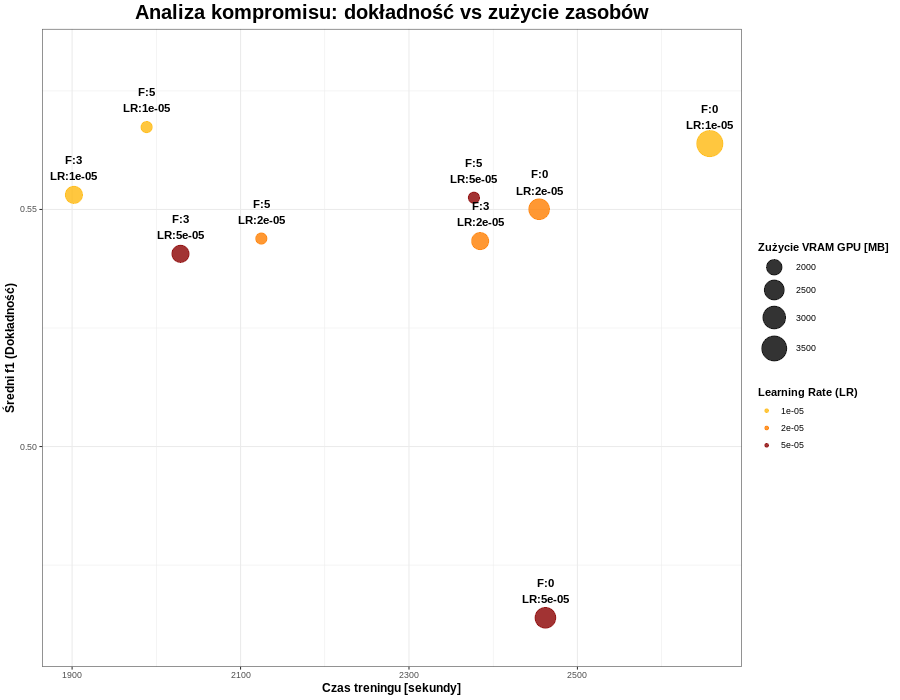

In [ ]:
%%R -w 900 -h 700 -u px

# Średnia f1 z modeli obcych, bez enron
df_jakość <- df_wyniki %>%
  filter(dataset != "enronSpamSubset") %>%
  group_by(frozen, lr) %>%
  summarise(Średnia_f1 = mean(f1, na.rm = TRUE),
    .groups = 'drop'
  )

# Zmiana nagłówków, żeby dało się połączyć tabele
df_zasoby1 <- df_zuzyciezasobow %>%
  rename(frozen = how_many_frozen, lr = learning_rate)

# Łączymy tabele
df_ostateczna <- df_jakość %>%
  inner_join(df_zasoby1, by = c("frozen", "lr"))

# Wykres
ggplot(df_ostateczna, aes(x = time_s, y = Średnia_f1)) +

  # Punkty (wielkość = VRAM, kolor = LR)
  geom_point(aes(color = factor(lr), size = gpu_max_mb), alpha = 0.8) +

  geom_text(aes(label = paste0("F:", frozen, "\nLR:", lr)),
            size = 4,
            fontface = "bold",
            vjust = -0.6) + # odległość opisu od środka kropki na wykresie

  # Kolory i wielkości
  scale_color_manual(values = c("1e-05" = "darkgoldenrod1",
                               "2e-05" = "darkorange1",
                               "5e-05" = "darkred")) +

  scale_size_continuous(range = c(5, 12), # zakres wielkości kropek
                        breaks = seq(1000, 4000, 500)) + # co ile chcemy zmianę wielkości kropki


  theme_bw() + # usuwamy szare tło
  labs(title = "Analiza kompromisu: dokładność vs zużycie zasobów",
       x = "Czas treningu [sekundy]",
       y = "Średni f1 (Dokładność)",
       color = "Learning Rate (LR)",
       size = "Zużycie VRAM GPU [MB]") +

  # Dodatkowe marginesy góra/dół, żeby teksty nie uciekły poza ramkę
  scale_y_continuous(expand = expansion(mult = c(0.1, # na dole
                                                 0.2))) + # na górze

  theme(
    plot.title = element_text(face = "bold",
                              size = 20,
                              hjust = 0.5), # wyśrodkowanie
    legend.position = "right",
    title = element_text(face = "bold"),
    axis.title = element_text(face = "bold", size = 12)
  )

### Idealny model

Szukamy takiego modelu, który w jak najkrótszym czasie i przy najmniejszym zużyciu zasobów osiągnie najlepszą dokładność.


### Wnioski

Na podstawie powyższego wykresu widać, że modele trenowane dla **lr** $= 1 \cdot 10^{-5}$ osiągają najlepsze średnie wartości f1 niezależnie od wykorzystania zasobów czy liczby zamrożonych warstw. Podobną sytuację obserwujemy dla **lr** $= 2 \cdot 10^{-5}$. Wynika z tego, że małe wartości parametru **lr** są bezpieczniejsze dla naszego BERTa.

Sama średnia wszystkich modeli jest dość niska (około $55%$), ponieważ ta miara jest wrażliwa na obserwacje odstające, jakimi są wyniki f1 dla zbioru `spam`.

Najgorzej wypada model **frozen**$= 0$ i **lr** $= 5 \cdot 10^{-5}$. Trening zajmuje dużo czasu, a sam model osiąga fatalny średni f1. Łączy się to z naszymi poprzednimi wnioski odnośnie dokładności dopasowania. To właśnie w tym punkcie modele osiągały najgorsze wyniki. Wynika to z faktu, że przy dostępnie do wszystkich warstw i dużej możliwości ingerowania w wagi w nich, model łatwo się rozregulowuje.

Warto zwrócić uwagę, że im mniej zamrożonych warstw tym większe zużycie zasobów niezależnie od wartości parametru **lr**.

Biorąc pod uwagę zużycie zasobów oraz dokładność dopasowania o tytuł najlepszego modelu biją się:

*   **frozen**$= 3$, **lr** $= 1 \cdot 10^{-5}$, **czas** $= 1900$ s, **średni f1** $\approx 55.5\%$, **zużycie GPU** $\in (2000, 2500]$,
*   **frozen**$= 5$, **lr** $= 1 \cdot 10^{-5}$, **czas** $\approx 1990$ s, **średni f1** $\approx 57\%$, **zużycie GPU** $\in [0, 2000]$,

Przy niewielkim wydłużeniu czasu treningu możemy osiągnąć niewielką poprawę w dopasowaniu, ale różnica w wykorzystaniu zasobów karty graficznej jest znacząca. Potwierdza to zatem wcześniej wysnuty wniosek, że ostrożne kroki uczenia w połączeniu z małą ingerencją w parametry bazowe (duże mrożenie) pozwala na lepsze uniwersalne dopasowanie modelu - lepszą klasyfikację obcych zbiorów danych.
